In [3]:
import os

data_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'

print(os.listdir(data_dir))

['val', '.DS_Store', 'test', 'train']


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' using device: {device}')

 using device: cuda


In [6]:
# Data augmentation and Normalization
train_transforms = transforms.Compose([
transforms.Resize((224, 224)),
transforms.RandomHorizontalFlip(),
transforms.RandomRotation(10),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [7]:
from torchvision import datasets

# Use the correct path
data_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'

train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=val_test_transforms)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=val_test_transforms)

print(f' training set size: {len(train_dataset)}')
print(f' validation set size: {len(val_dataset)}')
print(f' test set size: {len(test_dataset)}')
print(f' category: {train_dataset.classes}')

 training set size: 5216
 validation set size: 16
 test set size: 624
 category: ['NORMAL', 'PNEUMONIA']


In [8]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
# Define the Model (Customize the CNN, no need to download pre-trained weights)
import torch.nn as nn
import torch.nn.functional as F

class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()
        # Convolutional Layer 1:3-channel input (RGB), 32-channel output, 3x3 convolutional kernels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        # Convolutional Layer 2: Input 32, output 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Convolutional Layer 3: Input 64, output 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Pooling Layer
        self.pool = nn.MaxPool2d(2, 2)
        # dropout Layer 
        self.dropout = nn.Dropout(0.5)

        # Fully connected layer: The size of the input feature map needs to be calculated
        #Input 224x224, and after three pooling operations, it becomes 224/2/2/2 = 28
        #Since there are 128 channels, the feature dimension = 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # Convolution + activation + pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        # Zhan Ping
        x = x.view(-1, 128 * 28 * 28)
        # Fully Connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Creating Models
model = PneumoniaCNN()

# Move to GPU 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f' model created successfully!) device used: {device}')
print(f' model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M')

 model created successfully!) device used: cuda
 model parameters: 51.48M


In [10]:
num_epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Verification Stage
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_train_loss:.4f}, Val Accuracy: {val_acc:.2f}%')

Epoch 1/10, Loss: 0.3743, Val Accuracy: 62.50%
Epoch 2/10, Loss: 0.1668, Val Accuracy: 56.25%
Epoch 3/10, Loss: 0.1368, Val Accuracy: 62.50%
Epoch 4/10, Loss: 0.1225, Val Accuracy: 56.25%
Epoch 5/10, Loss: 0.1171, Val Accuracy: 56.25%
Epoch 6/10, Loss: 0.0983, Val Accuracy: 68.75%
Epoch 7/10, Loss: 0.0983, Val Accuracy: 62.50%
Epoch 8/10, Loss: 0.1053, Val Accuracy: 75.00%
Epoch 9/10, Loss: 0.0912, Val Accuracy: 62.50%
Epoch 10/10, Loss: 0.0782, Val Accuracy: 68.75%


              precision    recall  f1-score   support

      NORMAL       0.93      0.48      0.63       234
   PNEUMONIA       0.76      0.98      0.85       390

    accuracy                           0.79       624
   macro avg       0.84      0.73      0.74       624
weighted avg       0.82      0.79      0.77       624



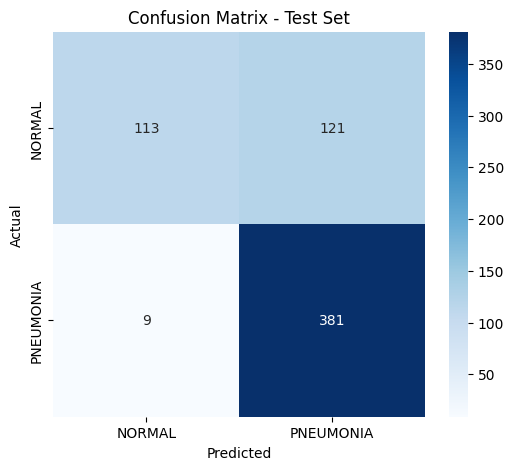

In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_dataset.classes, 
            yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

In [12]:
torch.save(model.state_dict(), 'pneumonia_cnn_model.pth')
print(' model has been saved as pneumonia_cnn_model.pth')

 model has been saved as pneumonia_cnn_model.pth
